# F1 Sponsor Stock Return Analysis

This notebook is written for the current project structure:

```text
F1-SPONSOR-STOCKS/
├── data/
│   ├── constructor_results.csv
│   ├── constructor_standings.csv
│   ├── constructors.csv
│   ├── qualifying.csv
│   ├── races.csv
│   ├── results.csv
│   └── sprint_results.csv
├── sponsor_mapping.xlsx
├── requirements.txt
└── f1_sponsor_analysis.ipynb
```

The goal is to build a clean race-by-team dataset, merge it with sponsor tickers, download Yahoo Finance data, and prepare a regression-ready dataset.

**What is new in this version:** standard errors are clustered by race weekend; sponsor firms are filtered using the `include_main_model` flag in the mapping file; Yahoo Finance prices are cached locally for reproducibility; and the analysis includes race-aligned three-day event returns, separate win/podium/points specifications, sponsor-stock and race fixed effects, winsorized-return sensitivity checks, and leave-one-sponsor-out robustness checks.


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.iolib.summary2 import summary_col
from IPython.display import HTML, display


START_YEAR = 2021
END_YEAR = 2025

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_FILE = PROJECT_ROOT / "sponsor_mapping.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Where we cache the Yahoo Finance download so the analysis is reproducible
# even without a live internet connection or if yfinance changes its output
# format later. See Section 8 for how this is used.
PRICE_CACHE_FILE = OUTPUT_DIR / "price_panel_cache.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR.resolve())
print("Sponsor mapping file:", MAPPING_FILE.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Sponsor mapping exists:", MAPPING_FILE.exists())

Project root: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks
Data directory: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/data
Sponsor mapping file: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/sponsor_mapping.xlsx
Data directory exists: True
Sponsor mapping exists: True


## 1. Load the local CSV files

The code below reads the CSV files directly from the `data/` folder. It does not use a `data["races"]` dictionary, because our local project stores each file as a normal CSV file inside the `data` folder.

In [36]:
required_files = {
    "races": "races.csv",
    "results": "results.csv",
    "constructors": "constructors.csv",
    "constructor_results": "constructor_results.csv",
    "constructor_standings": "constructor_standings.csv",
    "qualifying": "qualifying.csv",
    "sprint_results": "sprint_results.csv",
}

missing_files = [filename for filename in required_files.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "The following files are missing from the data/ folder: " + ", ".join(missing_files)
    )

races = pd.read_csv(DATA_DIR / "races.csv")
results = pd.read_csv(DATA_DIR / "results.csv")
constructors = pd.read_csv(DATA_DIR / "constructors.csv")
constructor_results = pd.read_csv(DATA_DIR / "constructor_results.csv")
constructor_standings = pd.read_csv(DATA_DIR / "constructor_standings.csv")
qualifying = pd.read_csv(DATA_DIR / "qualifying.csv")
sprint_results = pd.read_csv(DATA_DIR / "sprint_results.csv")

loaded_frames = {
    "races": races,
    "results": results,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "qualifying": qualifying,
    "sprint_results": sprint_results,
}

for name, df in loaded_frames.items():
    print(f"{name:25s} shape = {df.shape}")
    print("Columns:", list(df.columns))
    print("-" * 100)

races                     shape = (1171, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
----------------------------------------------------------------------------------------------------
results                   shape = (27392, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
----------------------------------------------------------------------------------------------------
constructors              shape = (214, 5)
Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
----------------------------------------------------------------------------------------------------
constructor_results       shape = (12942

## 2. Standardize column names when needed

Some Formula 1 datasets use Ergast-style names such as `raceId`, `constructorId`, and `year`. Other versions use `race_id`, `constructor_id`, and `season`. This section standardizes the key columns so the rest of the notebook works with either version.

One thing worth flagging explicitly: this Ergast-style data uses the literal string `"\N"` (not an empty cell) to mark missing values in several columns, such as qualifying times or sprint dates. `pd.to_numeric(..., errors="coerce")` turns those into proper `NaN` values wherever we use it below, which is why we apply it consistently to every numeric column we rely on instead of trusting the raw CSV values.

In [37]:
def standardize_f1_tables(races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results):
    races = races.copy()
    results = results.copy()
    constructors = constructors.copy()
    constructor_results = constructor_results.copy()
    constructor_standings = constructor_standings.copy()
    qualifying = qualifying.copy()
    sprint_results = sprint_results.copy()

    # races.csv
    races = races.rename(columns={
        "race_id": "raceId",
        "season": "year",
        "race_name": "race_name",
    })
    if "name" in races.columns and "race_name" not in races.columns:
        races = races.rename(columns={"name": "race_name"})
    if "raceId" not in races.columns or "year" not in races.columns:
        raise KeyError("races.csv must contain either raceId/year or race_id/season.")

    # results.csv
    results = results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })
    if "raceId" not in results.columns or "constructorId" not in results.columns:
        raise KeyError("results.csv must contain either raceId/constructorId or race_id/constructor_id.")

    # constructors.csv
    constructors = constructors.rename(columns={
        "constructor_id": "constructorRef",
        "constructor_ref": "constructorRef",
        "constructorId": "constructorId",
    })
    if "constructorId" not in constructors.columns:
        # Some cleaned datasets only have constructorRef-like identifiers. In that case, use them as the key.
        if "constructorRef" in constructors.columns:
            constructors["constructorId"] = constructors["constructorRef"]
        else:
            raise KeyError("constructors.csv must contain constructorId or constructor_id.")
    if "constructorRef" not in constructors.columns:
        constructors["constructorRef"] = constructors["constructorId"]
    if "name" not in constructors.columns:
        raise KeyError("constructors.csv must contain a name column.")

    # constructor_results.csv
    constructor_results = constructor_results.rename(columns={
        "constructor_results_id": "constructorResultsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # constructor_standings.csv
    constructor_standings = constructor_standings.rename(columns={
        "constructor_standings_id": "constructorStandingsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # qualifying.csv
    qualifying = qualifying.rename(columns={
        "qualify_id": "qualifyId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
    })

    # sprint_results.csv
    sprint_results = sprint_results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })

    # Harmonize key dtypes for safer merges.
    for df in [races, results, constructor_results, constructor_standings, qualifying, sprint_results]:
        if "raceId" in df.columns:
            df["raceId"] = df["raceId"].astype(str)
        if "constructorId" in df.columns:
            df["constructorId"] = df["constructorId"].astype(str)
    constructors["constructorId"] = constructors["constructorId"].astype(str)
    constructors["constructorRef"] = constructors["constructorRef"].astype(str)

    races["date"] = pd.to_datetime(races["date"], errors="coerce")
    races["year"] = pd.to_numeric(races["year"], errors="coerce").astype("Int64")

    return races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results

(
    races,
    results,
    constructors,
    constructor_results,
    constructor_standings,
    qualifying,
    sprint_results,
) = standardize_f1_tables(
    races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results
)

print("Standardization completed.")
print("races columns:", list(races.columns))
print("constructors columns:", list(constructors.columns))

Standardization completed.
races columns: ['raceId', 'year', 'round', 'circuitId', 'race_name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
constructors columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']


## 3. Check race result coverage for 2021–2025

Before doing any finance analysis, we first check whether the F1 race data has race results for the selected sample period.

In [38]:
recent_races = races[races["year"].between(START_YEAR, END_YEAR)].copy()

coverage = (
    recent_races.assign(has_results=recent_races["raceId"].isin(results["raceId"].unique()))
    .groupby(["year", "has_results"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "races_without_results", True: "races_with_results"})
)

for col in ["races_without_results", "races_with_results"]:
    if col not in coverage.columns:
        coverage[col] = 0

coverage["total_races_in_races_csv"] = coverage["races_without_results"] + coverage["races_with_results"]
coverage["result_coverage_rate"] = coverage["races_with_results"] / coverage["total_races_in_races_csv"]
coverage

has_results,races_with_results,races_without_results,total_races_in_races_csv,result_coverage_rate
year,,,,
2021,22,0,22,1.0
2022,22,0,22,1.0
2023,22,0,22,1.0
2024,24,0,24,1.0
2025,24,0,24,1.0


## 4. Build a race-by-team performance dataset

Each row will represent one constructor in one race. This is the key F1 performance table that will later be linked to sponsor companies.

We use `constructor_results.csv` as our primary source of points and only fall back to summing `results.csv` if a race-constructor pair is missing from `constructor_results.csv`. The two sources occasionally disagree, and the diagnostic below shows why: on sprint-race weekends, `constructor_results.csv` already includes the sprint points, while simply summing `results.csv` does not, since that file only covers the main Grand Prix. This is exactly the kind of thing we'd rather catch and explain than silently absorb, so the cell prints how often it happens. One consequence worth keeping in mind for later: our `win` and `podium` flags are built from `results.csv` only, so they describe the main Grand Prix result, not a sprint race result.

In [39]:
# Constructor-level race points from constructor_results.csv.
team_race_points = (
    constructor_results
    .merge(recent_races[["raceId", "year", "round", "race_name", "date"]], on="raceId", how="inner")
    .merge(constructors[["constructorId", "constructorRef", "name", "nationality"]], on="constructorId", how="left")
    .rename(columns={
        "name": "team",
        "points": "team_points_constructor_results",
    })
)

# Driver results are used to identify wins, podiums, and best finishing position.
required_result_cols = ["raceId", "constructorId", "positionOrder", "points"]
missing_result_cols = [col for col in required_result_cols if col not in results.columns]
if missing_result_cols:
    raise KeyError(f"results.csv is missing required columns: {missing_result_cols}")

results_for_recent_races = results.merge(
    recent_races[["raceId", "year", "round", "race_name", "date"]],
    on="raceId",
    how="inner",
)
results_for_recent_races["positionOrder"] = pd.to_numeric(results_for_recent_races["positionOrder"], errors="coerce")
results_for_recent_races["points"] = pd.to_numeric(results_for_recent_races["points"], errors="coerce")

team_performance = (
    results_for_recent_races
    .groupby(["raceId", "constructorId"], as_index=False)
    .agg(
        best_finish=("positionOrder", "min"),
        team_points_from_results=("points", "sum"),
        number_of_classified_drivers=("driverId", "count") if "driverId" in results_for_recent_races.columns else ("positionOrder", "count"),
    )
)

team_performance["win"] = (team_performance["best_finish"] == 1).astype(int)
team_performance["podium"] = (team_performance["best_finish"] <= 3).astype(int)

team_race = team_race_points.merge(
    team_performance,
    on=["raceId", "constructorId"],
    how="left",
)

# Prefer constructor_results points if available; otherwise fall back to the sum from results.csv.
team_race["team_points"] = team_race["team_points_constructor_results"].fillna(team_race["team_points_from_results"])

# Diagnostics: how often do the two point sources actually disagree, and why?
uses_fallback = team_race["team_points_constructor_results"].isna()
both_available = team_race["team_points_constructor_results"].notna() & team_race["team_points_from_results"].notna()
disagreement = both_available & ((team_race["team_points_constructor_results"] - team_race["team_points_from_results"]).abs() > 0.01)

print(f"Rows that needed the results.csv fallback (no constructor_results.csv entry): {uses_fallback.sum()} of {len(team_race)}")
print(f"Rows where the two sources disagree even though both are available: {disagreement.sum()} of {both_available.sum()}")
print("These disagreements are concentrated on sprint-race weekends, where constructor_results.csv already includes sprint points.")

cols_to_show = [
    "raceId", "year", "round", "date", "race_name", "constructorId", "constructorRef", "team",
    "team_points", "best_finish", "win", "podium"
]
team_race = team_race[cols_to_show].sort_values(["year", "round", "team"])

print("\nRace-by-team dataset shape:", team_race.shape)
team_race.head(10)

Rows that needed the results.csv fallback (no constructor_results.csv entry): 0 of 1140
Rows where the two sources disagree even though both are available: 82 of 1140
These disagreements are concentrated on sprint-race weekends, where constructor_results.csv already includes sprint points.

Race-by-team dataset shape: (1140, 12)


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0
8,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0
11,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0
13,1052,2021,1,2021-03-28,Bahrain Grand Prix,210,haas,Haas F1 Team,0.0,16,0,0
6,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,0,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,1,1
5,1052,2021,1,2021-03-28,Bahrain Grand Prix,9,red_bull,Red Bull,28.0,2,0,1
12,1052,2021,1,2021-03-28,Bahrain Grand Prix,3,williams,Williams,0.0,14,0,0


## 5. Add qualifying information as optional explanatory variables

Qualifying performance can be useful as a robustness check because it captures expectations before the race. The main model can focus on race results, while this variable can be used later as an additional control.

In [40]:
if {"raceId", "constructorId", "position"}.issubset(qualifying.columns):
    qualifying_temp = qualifying.copy()
    qualifying_temp["position"] = pd.to_numeric(qualifying_temp["position"], errors="coerce")
    team_qualifying = (
        qualifying_temp
        .merge(recent_races[["raceId"]], on="raceId", how="inner")
        .groupby(["raceId", "constructorId"], as_index=False)
        .agg(best_grid_position=("position", "min"))
    )
    team_qualifying["pole_position"] = (team_qualifying["best_grid_position"] == 1).astype(int)
    team_race = team_race.merge(team_qualifying, on=["raceId", "constructorId"], how="left")
else:
    team_race["best_grid_position"] = np.nan
    team_race["pole_position"] = np.nan

team_race.head()

,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium,best_grid_position,pole_position
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0,12,0
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0,5,0
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0,9,0
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0,10,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0,4,0


## 6. Load and clean the sponsor mapping file

Our current `sponsor_mapping.xlsx` may use different column names, such as `team_name_in_report` instead of `team`, or `ticker_yahoo` instead of `ticker`. This section accepts those names and standardizes them automatically.

This is also where we apply the `include_main_model` flag we built into the spreadsheet ourselves. Right now it only excludes one row: Kraken (ticker `COIN`), Williams' crypto-platform sponsor. Kraken itself isn't publicly listed, so `COIN` (Coinbase) is only a loose sector proxy, not a measurement of the actual sponsor — including it in the main regression would mean treating "the crypto sector moved" as if it were "Williams' sponsor moved." We keep the full, unfiltered table around as `sponsor_mapping_full` in case we want to bring Kraken back in later as a separate robustness check, but `sponsor_mapping` (used everywhere else in the notebook) only contains sponsors we are comfortable treating as a direct stock-market measurement of the relationship.

In [41]:
if not MAPPING_FILE.exists():
    raise FileNotFoundError("sponsor_mapping.xlsx was not found in the project root.")

sponsor_mapping_full = pd.read_excel(MAPPING_FILE)
sponsor_mapping_full.columns = [str(col).strip() for col in sponsor_mapping_full.columns]

# Accept both the simple column names and the more descriptive names used in the first version of the workbook.
rename_mapping = {
    "team_name_in_report": "team",
    "ticker_yahoo": "ticker",
    "team_constructor_id": "constructorRef",
}
sponsor_mapping_full = sponsor_mapping_full.rename(columns={k: v for k, v in rename_mapping.items() if k in sponsor_mapping_full.columns})

required_mapping_cols = ["sponsor", "start_year", "end_year"]
missing_mapping_cols = [col for col in required_mapping_cols if col not in sponsor_mapping_full.columns]
if missing_mapping_cols:
    raise KeyError(f"sponsor_mapping.xlsx is missing columns: {missing_mapping_cols}")

if "ticker" not in sponsor_mapping_full.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'ticker' or 'ticker_yahoo'.")
if "team" not in sponsor_mapping_full.columns and "constructorRef" not in sponsor_mapping_full.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'team', 'team_name_in_report', or 'team_constructor_id'.")

sponsor_mapping_full["start_year"] = pd.to_numeric(sponsor_mapping_full["start_year"], errors="coerce").astype("Int64")
sponsor_mapping_full["end_year"] = pd.to_numeric(sponsor_mapping_full["end_year"], errors="coerce").astype("Int64")
sponsor_mapping_full["ticker"] = sponsor_mapping_full["ticker"].astype(str).str.strip()
sponsor_mapping_full["sponsor"] = sponsor_mapping_full["sponsor"].astype(str).str.strip()

if "team" in sponsor_mapping_full.columns:
    sponsor_mapping_full["team"] = sponsor_mapping_full["team"].astype(str).str.strip()
if "constructorRef" in sponsor_mapping_full.columns:
    sponsor_mapping_full["constructorRef"] = sponsor_mapping_full["constructorRef"].astype(str).str.strip()

# Apply the include_main_model flag. If the column is missing entirely (e.g. an older
# version of the workbook), default to including everything rather than crashing.
if "include_main_model" not in sponsor_mapping_full.columns:
    print("Warning: 'include_main_model' column not found in sponsor_mapping.xlsx; including all rows by default.")
    sponsor_mapping_full["include_main_model"] = True
sponsor_mapping_full["include_main_model"] = sponsor_mapping_full["include_main_model"].astype(bool)

sponsor_mapping = sponsor_mapping_full[sponsor_mapping_full["include_main_model"]].copy()

n_excluded = (~sponsor_mapping_full["include_main_model"]).sum()
print(f"Sponsor mapping: {len(sponsor_mapping_full)} rows total, {n_excluded} excluded via include_main_model, {len(sponsor_mapping)} used in the main analysis.")
if n_excluded:
    excluded_cols = [c for c in ["team", "sponsor", "ticker"] if c in sponsor_mapping_full.columns]
    print("Excluded rows:")
    print(sponsor_mapping_full.loc[~sponsor_mapping_full["include_main_model"], excluded_cols])

print("\nSponsor mapping columns:", list(sponsor_mapping.columns))
sponsor_mapping.head(10)

Sponsor mapping: 9 rows total, 1 excluded via include_main_model, 8 used in the main analysis.
Excluded rows:
       team sponsor ticker
8  Williams  Kraken   COIN

Sponsor mapping columns: ['constructorRef', 'team', 'sponsor', 'ticker', 'exchange', 'start_year', 'end_year', 'include_main_model', 'sponsor_type', 'source_url', 'notes']


,constructorRef,team,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
0,red_bull,Red Bull Racing,Oracle,ORCL,NYSE,2022,2025,True,Title / technology sponsor,https://www.oracle.com/redbullracing/,Use from 2022 onward because Oracle became tit...
1,mercedes,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
2,mercedes,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
3,ferrari,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
4,ferrari,Ferrari,Santander,SAN,BME/NYSE,2022,2024,True,Banking sponsor,https://www.santander.com/,Use 2022–2024 because the Ferrari partnership ...
5,mclaren,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
6,mclaren,McLaren,Cisco,CSCO,NASDAQ,2024,2025,True,Technology sponsor,https://www.cisco.com/,Use from 2024 onward.
7,aston_martin,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.


## 7. Merge F1 performance with sponsor tickers

The preferred merge key is `constructorRef`, because it is stable and avoids small spelling differences in team names. If `constructorRef` is not available in the mapping file, the notebook falls back to the readable team name.

In [42]:
if "constructorRef" in sponsor_mapping.columns:
    analysis_base = team_race.merge(sponsor_mapping, on="constructorRef", how="left", suffixes=("", "_mapping"))
else:
    analysis_base = team_race.merge(sponsor_mapping, on="team", how="left", suffixes=("", "_mapping"))

analysis_base = analysis_base[
    (analysis_base["start_year"].notna())
    & (analysis_base["end_year"].notna())
    & (analysis_base["year"] >= analysis_base["start_year"])
    & (analysis_base["year"] <= analysis_base["end_year"])
].copy()

print("Sponsor-race observations:", analysis_base.shape[0])
print("Unique tickers:", sorted(analysis_base["ticker"].dropna().unique()))
analysis_base.head(10)

Sponsor-race observations: 778
Unique tickers: ['CRWD', 'CSCO', 'CTSH', 'DELL', 'ORCL', 'SAN', 'SHEL', 'TMV.DE']


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,team_mapping,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
16,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,117,aston_martin,Aston Martin,4.0,8,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
17,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,6,ferrari,Ferrari,22.0,4,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
20,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,1,mclaren,McLaren,23.0,3,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
22,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
23,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...


## 8. Download Yahoo Finance prices (with a local cache for reproducibility)

Yahoo Finance is a live, third-party data source: prices occasionally get restated, and the API itself has changed its column layout before. Since the assignment specifically asks us to hand in the data together with the code so everything can be reproduced exactly, we save the cleaned price panel to a local CSV (`outputs/price_panel_cache.csv`) the first time we build it, and simply read that file back in on every later run instead of hitting the API again.

If we ever add a new sponsor and need a ticker that isn't in the cache yet, the check below notices that and re-downloads automatically — we don't have to remember to delete anything by hand.

First, here's the function that turns the raw `yfinance` output into a clean long-format table (one row per ticker per trading day):

In [43]:
def extract_price_panel(price_data, tickers):
    """
    Convert yfinance output into a clean long-format price panel.

    This version handles yfinance MultiIndex columns in the format:
    (Ticker, Price), for example ('ORCL', 'Adj Close').
    """
    rows = []

    for ticker in tickers:
        if ticker not in price_data.columns.get_level_values(0):
            print(f"Skipping {ticker}: not found in downloaded data.")
            continue

        one = price_data[ticker].copy()

        price_col = "Adj Close" if "Adj Close" in one.columns else "Close"

        one = (
            one[[price_col]]
            .rename(columns={price_col: "adj_close"})
            .reset_index()
            .rename(columns={"Date": "trading_date"})
        )

        one["ticker"] = ticker
        rows.append(one)

    if not rows:
        raise ValueError("No valid price data was extracted.")

    out = pd.concat(rows, ignore_index=True)
    out["trading_date"] = pd.to_datetime(out["trading_date"])
    out = out.dropna(subset=["adj_close"]).copy()
    out = out.sort_values(["ticker", "trading_date"])

    # One-day return remains valid because it is evaluated
    # on the first post-race trading date.
    out["return_t1"] = out.groupby("ticker")["adj_close"].pct_change(1)

    # Do NOT calculate a generic three-day return here.
    # The three-day return must be aligned to each race event window.

    return out


In [44]:
tickers = sorted(analysis_base["ticker"].dropna().unique().tolist())
market_tickers = ["^GSPC", "^VIX"]
all_tickers = tickers + market_tickers

if not tickers:
    raise ValueError("No sponsor tickers were found after merging the sponsor mapping file.")

start_download = (analysis_base["date"].min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end_download = (analysis_base["date"].max() + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

use_cache = False
if PRICE_CACHE_FILE.exists():
    cached_panel = pd.read_csv(PRICE_CACHE_FILE, parse_dates=["trading_date"])
    if set(all_tickers).issubset(set(cached_panel["ticker"].unique())):
        price_panel = cached_panel
        use_cache = True
        print(f"Loaded cached price data from {PRICE_CACHE_FILE.name}: "
              f"{price_panel.shape[0]} rows, {price_panel['ticker'].nunique()} tickers.")
    else:
        missing_from_cache = sorted(set(all_tickers) - set(cached_panel["ticker"].unique()))
        print(f"Cache exists but is missing {missing_from_cache}; re-downloading instead.")

if not use_cache:
    print("Downloading:", all_tickers)
    print("From", start_download, "to", end_download)

    price_data = yf.download(
        all_tickers,
        start=start_download,
        end=end_download,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
    )
    print("Downloaded price data shape:", price_data.shape)

    price_panel = extract_price_panel(price_data, all_tickers)
    price_panel.to_csv(PRICE_CACHE_FILE, index=False)
    print(f"Saved a local snapshot to {PRICE_CACHE_FILE} so the analysis is reproducible offline.")

price_panel.head()

Loaded cached price data from price_panel_cache.csv: 11960 rows, 10 tickers.


,trading_date,adj_close,ticker,return_t1,pre_event_date,pre_event_close,t3_end_date,t3_end_close,return_t3_post
0,2021-03-18,190.210007,CRWD,NaN,NaN,NaN,2021-03-22,195.729996,NaN
1,2021-03-19,194.630005,CRWD,0.023237,2021-03-18,190.210007,2021-03-23,190.600006,0.002050
2,2021-03-22,195.729996,CRWD,0.005652,2021-03-19,194.630005,2021-03-24,181.600006,-0.066948
3,2021-03-23,190.600006,CRWD,-0.026210,2021-03-22,195.729996,2021-03-25,179.160004,-0.084657
4,2021-03-24,181.600006,CRWD,-0.047219,2021-03-23,190.600006,2021-03-26,177.684998,-0.067760


In [45]:
price_panel = price_panel.sort_values(["ticker", "trading_date"]).copy()

# Remove legacy columns created by the old three-day calculation.
price_panel = price_panel.drop(
    columns=["return_t3", "return_t3_post"],
    errors="ignore"
)

# Daily return: close on event day relative to prior trading close.
price_panel["return_t1"] = (
    price_panel.groupby("ticker")["adj_close"].pct_change(1)
)

# Event-window components.
# When a row is selected as the first post-race trading day:
# - pre_event_close is the close immediately before that day
# - t3_end_close is the close two trading sessions later
price_panel["pre_event_date"] = (
    price_panel.groupby("ticker")["trading_date"].shift(1)
)
price_panel["pre_event_close"] = (
    price_panel.groupby("ticker")["adj_close"].shift(1)
)

price_panel["t3_end_date"] = (
    price_panel.groupby("ticker")["trading_date"].shift(-2)
)
price_panel["t3_end_close"] = (
    price_panel.groupby("ticker")["adj_close"].shift(-2)
)

# Three post-race trading sessions:
# first post-race day through the second subsequent trading day.
price_panel["return_t3_post"] = (
    price_panel["t3_end_close"] / price_panel["pre_event_close"] - 1
)

# Overwrite the cache with the corrected variables.
price_panel.to_csv(PRICE_CACHE_FILE, index=False)

print(price_panel.columns.tolist())
price_panel.head()

['trading_date', 'adj_close', 'ticker', 'return_t1', 'pre_event_date', 'pre_event_close', 't3_end_date', 't3_end_close', 'return_t3_post']


,trading_date,adj_close,ticker,return_t1,pre_event_date,pre_event_close,t3_end_date,t3_end_close,return_t3_post
0,2021-03-18,190.210007,CRWD,NaN,NaT,NaN,2021-03-22,195.729996,NaN
1,2021-03-19,194.630005,CRWD,0.023237,2021-03-18,190.210007,2021-03-23,190.600006,0.002050
2,2021-03-22,195.729996,CRWD,0.005652,2021-03-19,194.630005,2021-03-24,181.600006,-0.066948
3,2021-03-23,190.600006,CRWD,-0.026210,2021-03-22,195.729996,2021-03-25,179.160004,-0.084657
4,2021-03-24,181.600006,CRWD,-0.047219,2021-03-23,190.600006,2021-03-26,177.684998,-0.067760


## 9. Match each race to the next available trading day

For each race date and ticker, the notebook selects the first available trading day after the race. This gives a clean `t+1` return measure.

In [46]:
def get_post_race_window(race_date, ticker, price_panel):
    """
    Finds the first trading day after a race and returns:
    - one-day post-race return
    - cumulative three-trading-day post-race return
    - dates and prices needed for auditing
    """
    candidate = price_panel[
        (price_panel["ticker"] == ticker)
        & (price_panel["trading_date"] > race_date)
    ].sort_values("trading_date")

    if candidate.empty:
        return pd.Series({
            "event_trading_date": pd.NaT,
            "pre_event_date": pd.NaT,
            "t3_end_date": pd.NaT,
            "pre_event_close": np.nan,
            "event_close": np.nan,
            "t3_end_close": np.nan,
            "return_1d": np.nan,
            "return_3d": np.nan,
        })

    first = candidate.iloc[0]

    return pd.Series({
        "event_trading_date": first["trading_date"],
        "pre_event_date": first["pre_event_date"],
        "t3_end_date": first["t3_end_date"],
        "pre_event_close": first["pre_event_close"],
        "event_close": first["adj_close"],
        "t3_end_close": first["t3_end_close"],
        "return_1d": first["return_t1"],
        "return_3d": first["return_t3_post"],
    })


# 1. Sponsor-stock event windows
stock_windows = analysis_base.apply(
    lambda row: get_post_race_window(
        row["date"],
        row["ticker"],
        price_panel
    ),
    axis=1,
).rename(columns={
    "event_trading_date": "stock_trading_date",
    "pre_event_date": "stock_pre_event_date",
    "t3_end_date": "stock_t3_end_date",
    "pre_event_close": "stock_pre_event_close",
    "event_close": "stock_event_close",
    "t3_end_close": "stock_t3_end_close",
    "return_1d": "stock_return_t1",
    "return_3d": "stock_return_t3",
})

analysis_finance = pd.concat(
    [
        analysis_base.reset_index(drop=True),
        stock_windows.reset_index(drop=True),
    ],
    axis=1,
)


# 2. Market event windows — same three-session construction
market_windows = analysis_base.apply(
    lambda row: get_post_race_window(
        row["date"],
        "^GSPC",
        price_panel
    ),
    axis=1,
).rename(columns={
    "event_trading_date": "market_trading_date",
    "pre_event_date": "market_pre_event_date",
    "t3_end_date": "market_t3_end_date",
    "pre_event_close": "market_pre_event_close",
    "event_close": "market_event_close",
    "t3_end_close": "market_t3_end_close",
    "return_1d": "market_return_t1",
    "return_3d": "market_return_t3",
})


# 3. VIX date and one-day return
vix_windows = analysis_base.apply(
    lambda row: get_post_race_window(
        row["date"],
        "^VIX",
        price_panel
    ),
    axis=1,
)[["event_trading_date", "return_1d", "return_3d"]].rename(columns={
    "event_trading_date": "vix_trading_date",
    "return_1d": "vix_return_t1",
    "return_3d": "vix_return_t3",
})


# 4. Merge market and VIX data
analysis_finance = pd.concat(
    [
        analysis_finance.reset_index(drop=True),
        market_windows.reset_index(drop=True),
        vix_windows.reset_index(drop=True),
    ],
    axis=1,
)

analysis_finance = analysis_finance.loc[
    :, ~analysis_finance.columns.duplicated()
].copy()


# 5. VIX closing level on the first post-race market day
def get_vix_level(trading_date, price_panel):
    if pd.isna(trading_date):
        return np.nan

    match = price_panel[
        (price_panel["ticker"] == "^VIX")
        & (price_panel["trading_date"] == trading_date)
    ]

    return np.nan if match.empty else match.iloc[0]["adj_close"]


analysis_finance["vix_level_t1"] = analysis_finance["vix_trading_date"].apply(
    lambda d: get_vix_level(d, price_panel)
)

analysis_finance.head()

,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,market_t3_end_date,market_pre_event_close,market_event_close,market_t3_end_close,market_return_t1,market_return_t3,vix_trading_date,vix_return_t1,vix_return_t3,vix_level_t1
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,2021-03-31,3974.540039,3971.090088,3972.889893,-0.000868,-0.000415,2021-03-29,0.099682,0.028632,20.74
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,2021-03-31,3974.540039,3971.090088,3972.889893,-0.000868,-0.000415,2021-03-29,0.099682,0.028632,20.74
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,2021-03-31,3974.540039,3971.090088,3972.889893,-0.000868,-0.000415,2021-03-29,0.099682,0.028632,20.74
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,2021-03-31,3974.540039,3971.090088,3972.889893,-0.000868,-0.000415,2021-03-29,0.099682,0.028632,20.74
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,2021-03-31,3974.540039,3971.090088,3972.889893,-0.000868,-0.000415,2021-03-29,0.099682,0.028632,20.74


In [47]:
audit = analysis_finance.dropna(
    subset=[
        "stock_pre_event_date",
        "stock_trading_date",
        "stock_t3_end_date",
        "stock_pre_event_close",
        "stock_t3_end_close",
        "stock_return_t3",
        "market_pre_event_close",
        "market_t3_end_close",
        "market_return_t3",
    ]
).copy()

assert (audit["stock_pre_event_date"] < audit["stock_trading_date"]).all()
assert (audit["stock_trading_date"] < audit["stock_t3_end_date"]).all()

assert np.allclose(
    audit["stock_return_t3"],
    audit["stock_t3_end_close"] / audit["stock_pre_event_close"] - 1
)

assert np.allclose(
    audit["market_return_t3"],
    audit["market_t3_end_close"] / audit["market_pre_event_close"] - 1
)

print("Three-day sponsor and market windows passed all audit checks.")

audit[
    [
        "race_name",
        "date",
        "ticker",
        "stock_pre_event_date",
        "stock_trading_date",
        "stock_t3_end_date",
        "stock_return_t1",
        "stock_return_t3",
        "market_return_t1",
        "market_return_t3",
    ]
].head(10)

Three-day sponsor and market windows passed all audit checks.


,race_name,date,ticker,stock_pre_event_date,stock_trading_date,stock_t3_end_date,stock_return_t1,stock_return_t3,market_return_t1,market_return_t3
0,Bahrain Grand Prix,2021-03-28,CTSH,2021-03-26,2021-03-29,2021-03-31,-0.014891,-0.014134,-0.000868,-0.000415
1,Bahrain Grand Prix,2021-03-28,SHEL,2021-03-26,2021-03-29,2021-03-31,-0.006863,-0.038970,-0.000868,-0.000415
2,Bahrain Grand Prix,2021-03-28,DELL,2021-03-26,2021-03-29,2021-03-31,-0.008765,-0.009439,-0.000868,-0.000415
3,Bahrain Grand Prix,2021-03-28,TMV.DE,2021-03-26,2021-03-29,2021-03-31,0.004394,0.000549,-0.000868,-0.000415
4,Bahrain Grand Prix,2021-03-28,CRWD,2021-03-26,2021-03-29,2021-03-31,-0.021583,0.027155,-0.000868,-0.000415
5,Emilia Romagna Grand Prix,2021-04-18,CTSH,2021-04-16,2021-04-19,2021-04-21,-0.002729,-0.016993,-0.005307,-0.002879
6,Emilia Romagna Grand Prix,2021-04-18,SHEL,2021-04-16,2021-04-19,2021-04-21,0.001270,-0.018791,-0.005307,-0.002879
7,Emilia Romagna Grand Prix,2021-04-18,DELL,2021-04-16,2021-04-19,2021-04-21,0.019720,-0.000099,-0.005307,-0.002879
8,Emilia Romagna Grand Prix,2021-04-18,TMV.DE,2021-04-16,2021-04-19,2021-04-21,0.002322,-0.022704,-0.005307,-0.002879
9,Emilia Romagna Grand Prix,2021-04-18,CRWD,2021-04-16,2021-04-19,2021-04-21,-0.008504,-0.022444,-0.005307,-0.002879


In [48]:
analysis_finance = analysis_finance.loc[:, ~analysis_finance.columns.duplicated()].copy()

## 10. Summary statistics and visual checks

These tables and plots help us understand the estimation sample before running any regressions. Beyond the original histogram and scatter plot, we add a box plot that splits returns by race outcome and a time-series view of how each sponsor's stock actually moved over the sample period — both of which are easy to read and give a first, purely descriptive impression of whether winning "looks like" it matters.

In [ ]:
regression_data = analysis_finance.dropna(
    subset=[
        "stock_return_t1",
        "stock_return_t3",
        "market_return_t1",
        "market_return_t3",
        "vix_level_t1"
    ]
).copy()

regression_data = regression_data.loc[
    :,
    ~regression_data.columns.duplicated()
].copy()

summary_cols = [
    "stock_return_t1",
    "stock_return_t3",
    "market_return_t1",
    "market_return_t3",
    "vix_level_t1",
    "team_points",
    "best_finish",
    "win",
    "podium",
    "best_grid_position",
    "pole_position",
]

summary_cols = [col for col in summary_cols if col in regression_data.columns]

summary_stats = regression_data[summary_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
stock_return_t1,778.0,0.000721,0.022116,-0.134608,-0.009447,0.000777,0.011640,0.118588
stock_return_t3,778.0,0.001991,0.043255,-0.190128,-0.016908,0.001026,0.020368,0.410352
abnormal_return_t1,778.0,-0.000195,0.019711,-0.145400,-0.008890,0.000100,0.009440,0.125510
abnormal_return_t3,778.0,-0.000139,0.039485,-0.195439,-0.015971,0.000227,0.016833,0.402555
market_return_t1,778.0,0.000915,0.009518,-0.038768,-0.003065,0.000888,0.005164,0.025884
market_return_t3,778.0,0.002129,0.017464,-0.045633,-0.008550,0.002370,0.011678,0.075446
vix_level_t1,778.0,19.286067,5.947401,12.150000,15.087500,17.560000,21.980000,46.980000
team_points,778.0,20.036632,13.274292,0.000000,10.000000,18.000000,29.750000,58.000000
best_finish,778.0,4.656812,3.787361,1.000000,2.000000,4.000000,6.000000,19.000000
win,778.0,0.190231,0.392736,0.000000,0.000000,0.000000,0.000000,1.000000


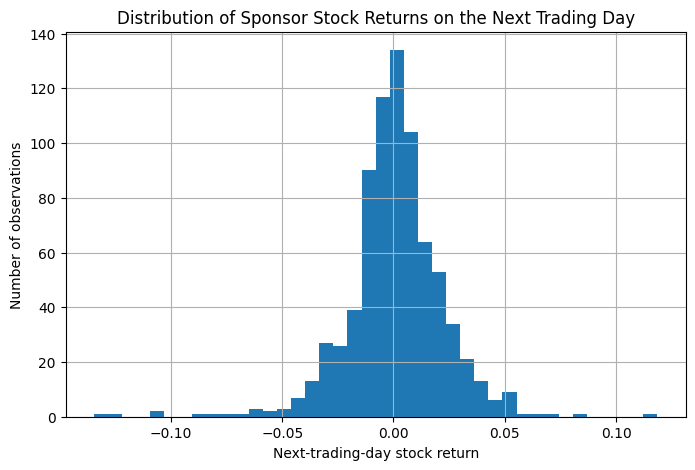

In [50]:
plt.figure(figsize=(8, 5))
regression_data["stock_return_t1"].dropna().hist(bins=40)
plt.title("Distribution of Sponsor Stock Returns on the Next Trading Day")
plt.xlabel("Next-trading-day stock return")
plt.ylabel("Number of observations")
plt.show()

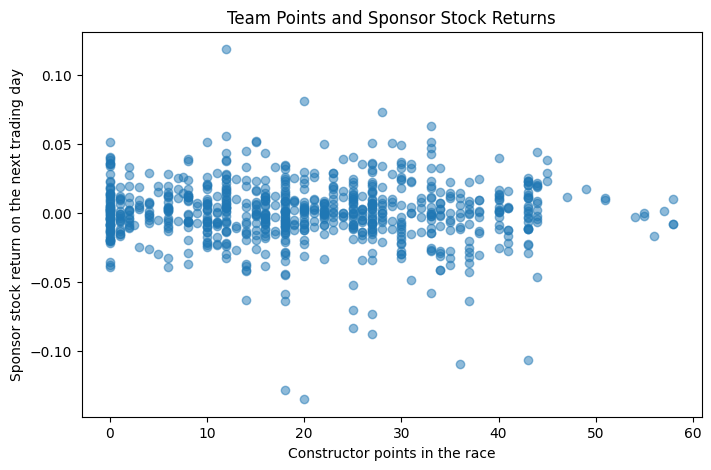

In [51]:
plt.figure(figsize=(8, 5))
plt.scatter(regression_data["team_points"], regression_data["stock_return_t1"], alpha=0.5)
plt.title("Team Points and Sponsor Stock Returns")
plt.xlabel("Constructor points in the race")
plt.ylabel("Sponsor stock return on the next trading day")
plt.show()

Two more descriptive checks before we move to regressions: does the *distribution* of next-day returns actually shift when the team wins, and what did each sponsor's stock do over the whole sample, independent of any single race?

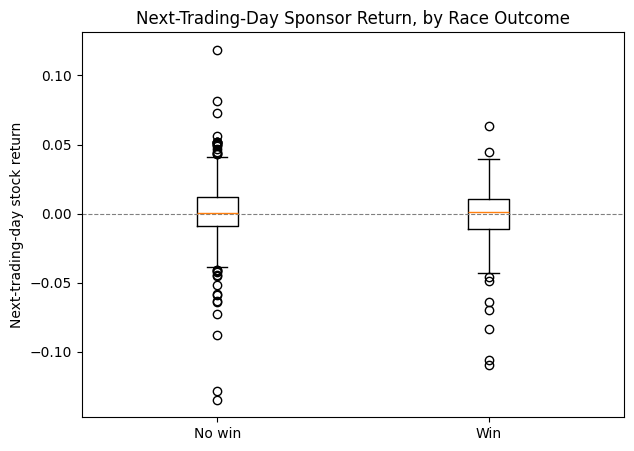

Median return after a win:     0.1057%  (n=148)
Median return after no win:    0.0758%  (n=630)


In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
no_win = regression_data.loc[regression_data["win"] == 0, "stock_return_t1"].dropna()
win = regression_data.loc[regression_data["win"] == 1, "stock_return_t1"].dropna()

ax.boxplot([no_win, win])
ax.set_xticks([1, 2])
ax.set_xticklabels(["No win", "Win"])
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Next-Trading-Day Sponsor Return, by Race Outcome")
ax.set_ylabel("Next-trading-day stock return")
plt.show()

print(f"Median return after a win:    {win.median(): .4%}  (n={len(win)})")
print(f"Median return after no win:   {no_win.median(): .4%}  (n={len(no_win)})")

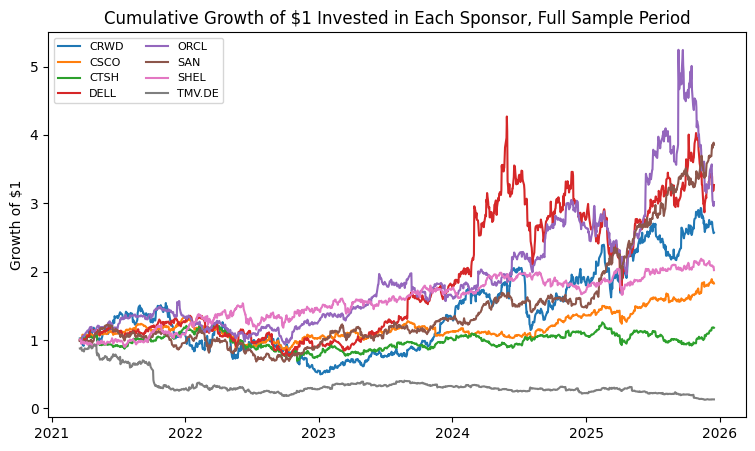

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
for ticker, sub in price_panel[price_panel["ticker"].isin(tickers)].groupby("ticker"):
    sub = sub.sort_values("trading_date").dropna(subset=["return_t1"])
    cumulative_growth = (1 + sub["return_t1"]).cumprod()
    ax.plot(sub["trading_date"], cumulative_growth, label=ticker)

ax.set_title("Cumulative Growth of $1 Invested in Each Sponsor, Full Sample Period")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.show()

## 11. Baseline Pooled OLS Models and Empirical Assumptions

These pooled regressions are used as baseline estimates. The preferred specifications are the sponsor-stock and race fixed-effects models reported in Section 13.

Before interpreting the coefficients, it is important to clarify what the regressions estimate and what they cannot establish. This section documents the empirical approach used in the notebook and keeps the code aligned with the paper's methods discussion. The pooled OLS regressions below are baseline estimates; the preferred sponsor-stock and race fixed-effects specifications are reported in Section 13.

**The estimating equations.** The primary outcome is the sponsor's stock return on the first trading day after race weekend `r`. We estimate separate ordinary least squares specifications for alternative measures of Formula 1 performance:

`stock_return_t1 = β0 + β1 × performance + β2 × market_return_t1 + β3 × vix_level_t1 + error`

Here, `performance` is measured separately as: (1) a race-win indicator, (2) a podium indicator, or (3) constructor points earned during the race weekend. Constructor points are scaled in units of ten points, so the points coefficient represents the estimated association between ten additional constructor points and the sponsor's next-trading-day stock return.

We do not include win, podium, and constructor points in the same adjusted specification because they are mechanically related. A win necessarily implies a podium and usually coincides with a high points total. Estimating the three measures separately gives each coefficient a clearer interpretation.

The three-day robustness analysis uses the same structure but replaces `stock_return_t1` and `market_return_t1` with cumulative three-trading-day post-race returns, measured over the same event window.


**Is strict exogeneity (MLR.4) plausible?** Reverse causality is unlikely: a sponsor's stock return after a race cannot cause that race's result. However, strict exogeneity remains a strong assumption. Unobserved news released around a race weekend, such as company announcements, sector developments, or broader macroeconomic shocks, could affect sponsor returns and may not be fully captured by the S&P 500 return and VIX. Therefore, the estimated coefficients should be interpreted as conditional associations rather than causal effects of Formula 1 performance on firm value.

The scale of the sponsor firms also matters for interpretation. Oracle, Shell, Cognizant, and the other sponsors are large companies whose daily returns are likely dominated by earnings news, macroeconomic conditions, and sector-wide movements. Any short-run effect of an individual race result may therefore be small relative to normal stock-return volatility. A statistically insignificant estimate should be interpreted as imprecise evidence of no detectable association in this sample, rather than proof that Formula 1 performance has no effect on sponsor value.

**Selection.** Only six constructors (Red Bull, Mercedes, Ferrari, McLaren, Aston Martin, and Williams) have a sponsor whose publicly traded stock can be observed in the sample. The remaining teams are excluded because no sufficiently clear, listed sponsor could be matched to them. These included constructors are not a random sample of Formula 1 teams; they are generally better-funded and more sponsor-attractive. This does not necessarily create endogeneity within the regression, but it limits external validity: the findings apply most directly to well-resourced teams with clearly identifiable listed sponsors.

**Why we cluster standard errors by race date.** Each race weekend produces several sponsor observations at the same time. These observations share the same market return and VIX level by construction, and team outcomes are also related within a race because only one constructor can win and only a limited number can finish on the podium. As a result, residuals may be correlated across sponsors observed after the same race weekend.

We therefore cluster standard errors at the race level (`raceId`). This allows residuals to be correlated within a race while assuming independence across races. Clustered standard errors provide more conservative inference than ordinary heteroskedasticity-robust standard errors when observations within the same race share common shocks.


In [69]:
def run_ols(df, y_col, x_cols, cluster_col=None):
    needed_cols = [y_col] + x_cols + ([cluster_col] if cluster_col else [])
    model_df = df[needed_cols].dropna().copy()

    y = model_df[y_col]
    X = sm.add_constant(model_df[x_cols])

    if cluster_col:
        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_df[cluster_col]}
        )
    else:
        model = sm.OLS(y, X).fit(cov_type="HC1")

    return model, model_df


# Scale points so the coefficient represents the effect of
# 10 additional constructor points rather than one point.
regression_data["team_points_10"] = regression_data["team_points"] / 10

# Remove stale year dummy columns from a previous run, if present.
old_year_dummy_cols = [
    col for col in regression_data.columns
    if col.startswith("year_")
]
regression_data = regression_data.drop(
    columns=old_year_dummy_cols,
    errors="ignore"
)

controls_t1 = [
    "market_return_t1",
    "vix_level_t1",
]

# Model 1: simple, unadjusted association with a race win.
model_1, model_1_df = run_ols(
    regression_data,
    "stock_return_t1",
    ["win"],
    cluster_col="raceId",
)

# Model 2: win, controlling for common market conditions.
model_2, model_2_df = run_ols(
    regression_data,
    "stock_return_t1",
    ["win"] + controls_t1,
    cluster_col="raceId",
)

# Model 3: podium, estimated separately from win and points.
model_3, model_3_df = run_ols(
    regression_data,
    "stock_return_t1",
    ["podium"] + controls_t1,
    cluster_col="raceId",
)

# Model 4: constructor points, estimated separately.
model_4, model_4_df = run_ols(
    regression_data,
    "stock_return_t1",
    ["team_points_10"] + controls_t1,
    cluster_col="raceId",
)

print("Models estimated successfully.")
print(f"Model 1 observations: {int(model_1.nobs)}")
print(f"Model 2 observations: {int(model_2.nobs)}")
print(f"Model 3 observations: {int(model_3.nobs)}")
print(f"Model 4 observations: {int(model_4.nobs)}")

Models estimated successfully.
Model 1 observations: 778
Model 2 observations: 778
Model 3 observations: 778
Model 4 observations: 778


## Three-Day Post-Race Return Robustness Check

This robustness analysis examines cumulative sponsor-stock returns over
the first three trading sessions after a Formula 1 race. Wins, podiums,
and constructor points are estimated in separate specifications.

The S&P 500 return is calculated over the identical three-trading-day
window as the sponsor-stock return.

In [55]:
# Three-day robustness regressions.
# Each performance measure is estimated separately, using
# the matching three-day market-return control.

controls_t3 = [
    "market_return_t3",
    "vix_level_t1",
]

t3_model_1, t3_model_1_df = run_ols(
    regression_data,
    "stock_return_t3",
    ["win"] + controls_t3,
    cluster_col="raceId",
)

t3_model_2, t3_model_2_df = run_ols(
    regression_data,
    "stock_return_t3",
    ["podium"] + controls_t3,
    cluster_col="raceId",
)

t3_model_3, t3_model_3_df = run_ols(
    regression_data,
    "stock_return_t3",
    ["team_points_10"] + controls_t3,
    cluster_col="raceId",
)

t3_comparison = summary_col(
    [t3_model_1, t3_model_2, t3_model_3],
    model_names=[
        "(1) Win",
        "(2) Podium",
        "(3) Points/10",
    ],
    stars=True,
    float_format="%0.4f",
    info_dict={
        "N": lambda m: f"{int(m.nobs)}",
    },
)

print(t3_comparison)

t3_comparison_df = t3_comparison.tables[0]
t3_comparison_df


                  (1) Win  (2) Podium (3) Points/10
---------------------------------------------------
const            -0.0026   -0.0034    -0.0042      
                 (0.0042)  (0.0043)   (0.0045)     
win              0.0014                            
                 (0.0046)                          
market_return_t3 1.0067*** 1.0057***  1.0078***    
                 (0.0690)  (0.0686)   (0.0688)     
vix_level_t1     0.0001    0.0001     0.0001       
                 (0.0002)  (0.0002)   (0.0002)     
podium                     0.0022                  
                           (0.0032)                
team_points_10                        0.0009       
                                      (0.0009)     
R-squared        0.1672    0.1676     0.1678       
R-squared Adj.   0.1639    0.1644     0.1645       
N                778       778        778          
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


,(1) Win,(2) Podium,(3) Points/10
const,-0.0026,-0.0034,-0.0042
,(0.0042),(0.0043),(0.0045)
win,0.0014,,
,(0.0046),,
market_return_t3,1.0067***,1.0057***,1.0078***
,(0.0690),(0.0686),(0.0688)
vix_level_t1,0.0001,0.0001,0.0001
,(0.0002),(0.0002),(0.0002)
podium,,0.0022,
,,(0.0032),


In [56]:


warnings.filterwarnings("ignore")

START_YEAR = 2021
END_YEAR = 2025

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_FILE = PROJECT_ROOT / "sponsor_mapping.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Where we cache the Yahoo Finance download so the analysis is reproducible
# even without a live internet connection or if yfinance changes its output
# format later. See Section 8 for how this is used.
PRICE_CACHE_FILE = OUTPUT_DIR / "price_panel_cache.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR.resolve())
print("Sponsor mapping file:", MAPPING_FILE.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Sponsor mapping exists:", MAPPING_FILE.exists())

Project root: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks
Data directory: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/data
Sponsor mapping file: /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/sponsor_mapping.xlsx
Data directory exists: True
Sponsor mapping exists: True


## 12. Side-by-Side Model Comparison

The table below compares the next-trading-day sponsor-return estimates
across alternative measures of Formula 1 performance. Column 1 shows
the unadjusted relationship between a race win and sponsor returns.
Columns 2 to 4 control for market returns and the VIX, while estimating
wins, podiums, and constructor points in separate specifications.

In [57]:
comparison = summary_col(
    [model_1, model_2, model_3, model_4],
    model_names=[
        "(1) Win only",
        "(2) Win + controls",
        "(3) Podium + controls",
        "(4) Points/10 + controls",
    ],
    stars=True,
    float_format="%0.4f",
    info_dict={
        "N": lambda m: f"{int(m.nobs)}",
    },
)

print(comparison)

comparison_df = comparison.tables[0]
comparison_df


                 (1) Win only (2) Win + controls (3) Podium + controls (4) Points/10 + controls
-----------------------------------------------------------------------------------------------
const            0.0014       0.0030             0.0031                0.0032                  
                 (0.0012)     (0.0021)           (0.0021)              (0.0023)                
win              -0.0036      -0.0033                                                          
                 (0.0023)     (0.0022)                                                         
market_return_t1              1.0361***          1.0388***             1.0366***               
                              (0.0610)           (0.0607)              (0.0611)                
vix_level_t1                  -0.0001            -0.0001               -0.0001                 
                              (0.0001)           (0.0001)              (0.0001)                
podium                                 

,(1) Win only,(2) Win + controls,(3) Podium + controls,(4) Points/10 + controls
const,0.0014,0.0030,0.0031,0.0032
,(0.0012),(0.0021),(0.0021),(0.0023)
win,-0.0036,-0.0033,,
,(0.0023),(0.0022),,
market_return_t1,,1.0361***,1.0388***,1.0366***
,,(0.0610),(0.0607),(0.0611)
vix_level_t1,,-0.0001,-0.0001,-0.0001
,,(0.0001),(0.0001),(0.0001)
podium,,,-0.0015,
,,,(0.0016),


## 13. Fixed-Effects Specifications

The pooled regressions control directly for market returns and the VIX. As a stronger specification, we also estimate sponsor-stock and race fixed-effects models.

Sponsor-stock fixed effects control for time-invariant differences across sponsor firms, such as their typical volatility, industry, and average return behavior. Race fixed effects control for all shocks shared by sponsors after the same race weekend, including broad market conditions, macroeconomic news, and common Formula 1 attention.

Because market returns and the VIX vary only by race date in this dataset, they are absorbed by race fixed effects and are not included separately in these models. Performance measures are again estimated in separate specifications.

In [58]:
def run_fixed_effects_ols(df, y_col, performance_col, cluster_col="raceId"):
    """
    OLS with sponsor-stock and race fixed effects.
    Standard errors are clustered by race.
    """

    needed_cols = list(dict.fromkeys([
        y_col,
        performance_col,
        "ticker",
        "raceId",
        cluster_col,
    ]))

    model_df = df[needed_cols].dropna().copy()

    formula = (
        f"{y_col} ~ {performance_col} "
        f"+ C(ticker) + C(raceId)"
    )

    model = smf.ols(
        formula=formula,
        data=model_df,
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": model_df[cluster_col],
            "use_correction": True,
        },
    )

    return model, model_df


# -----------------------------
# Next-trading-day FE models
# -----------------------------

fe_t1_win, fe_t1_win_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1",
    "win",
)

fe_t1_podium, fe_t1_podium_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1",
    "podium",
)

fe_t1_points, fe_t1_points_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1",
    "team_points_10",
)


# -----------------------------
# Three-day FE robustness models
# -----------------------------

fe_t3_win, fe_t3_win_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3",
    "win",
)

fe_t3_podium, fe_t3_podium_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3",
    "podium",
)

fe_t3_points, fe_t3_points_df = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3",
    "team_points_10",
)

print("Fixed-effects models estimated successfully.")
print("Number of race clusters:", regression_data["raceId"].nunique())

Fixed-effects models estimated successfully.
Number of race clusters: 114


In [59]:
def significance_stars(p_value):
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


def make_fe_results_table(models, model_labels, performance_vars):
    rows = []

    for model, label, variable in zip(models, model_labels, performance_vars):
        confidence_interval = model.conf_int().loc[variable]

        rows.append({
            "Model": label,
            "Performance measure": variable,
            "Coefficient": model.params[variable],
            "Clustered SE": model.bse[variable],
            "p-value": model.pvalues[variable],
            "Significance": significance_stars(model.pvalues[variable]),
            "95% CI lower": confidence_interval.iloc[0],
            "95% CI upper": confidence_interval.iloc[1],
            "Observations": int(model.nobs),
            "Adjusted R²": model.rsquared_adj,
            "Sponsor-stock FE": "Yes",
            "Race FE": "Yes",
        })

    return pd.DataFrame(rows)


fe_t1_table = make_fe_results_table(
    models=[
        fe_t1_win,
        fe_t1_podium,
        fe_t1_points,
    ],
    model_labels=[
        "Next-day: Win",
        "Next-day: Podium",
        "Next-day: Points / 10",
    ],
    performance_vars=[
        "win",
        "podium",
        "team_points_10",
    ],
)

fe_t3_table = make_fe_results_table(
    models=[
        fe_t3_win,
        fe_t3_podium,
        fe_t3_points,
    ],
    model_labels=[
        "Three-day: Win",
        "Three-day: Podium",
        "Three-day: Points / 10",
    ],
    performance_vars=[
        "win",
        "podium",
        "team_points_10",
    ],
)

print("Next-trading-day fixed-effects results:")
display(fe_t1_table.round(4))

print("Three-day fixed-effects results:")
display(fe_t3_table.round(4))

Next-trading-day fixed-effects results:


,Model,Performance measure,Coefficient,Clustered SE,p-value,Significance,95% CI lower,95% CI upper,Observations,Adjusted R²,Sponsor-stock FE,Race FE
0,Next-day: Win,win,-0.0045,0.0027,0.1019,,-0.0098,0.0009,778,0.1973,Yes,Yes
1,Next-day: Podium,podium,-0.0027,0.0020,0.1748,,-0.0067,0.0012,778,0.1952,Yes,Yes
2,Next-day: Points / 10,team_points_10,-0.0007,0.0008,0.3493,,-0.0022,0.0008,778,0.1933,Yes,Yes


Three-day fixed-effects results:


,Model,Performance measure,Coefficient,Clustered SE,p-value,Significance,95% CI lower,95% CI upper,Observations,Adjusted R²,Sponsor-stock FE,Race FE
0,Three-day: Win,win,-0.0011,0.0048,0.8137,,-0.0105,0.0082,778,0.1580,Yes,Yes
1,Three-day: Podium,podium,0.0004,0.0037,0.9202,,-0.0070,0.0077,778,0.1579,Yes,Yes
2,Three-day: Points / 10,team_points_10,0.0003,0.0013,0.8218,,-0.0023,0.0029,778,0.1579,Yes,Yes


In [60]:
models_to_verify = {
    "FE next-day win": fe_t1_win,
    "FE next-day podium": fe_t1_podium,
    "FE next-day points": fe_t1_points,
    "FE three-day win": fe_t3_win,
    "FE three-day podium": fe_t3_podium,
    "FE three-day points": fe_t3_points,
}

for model_name, model in models_to_verify.items():
    variables = model.model.exog_names

    has_ticker_fe = any("C(ticker)" in item for item in variables)
    has_race_fe = any("C(raceId)" in item for item in variables)
    has_market_control = any("market_return" in item for item in variables)
    has_vix_control = any("vix_level" in item for item in variables)

    print(f"\n{model_name}")
    print("Sponsor-stock fixed effects:", has_ticker_fe)
    print("Race fixed effects:", has_race_fe)
    print("Market return included separately:", has_market_control)
    print("VIX included separately:", has_vix_control)


FE next-day win
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False

FE next-day podium
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False

FE next-day points
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False

FE three-day win
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False

FE three-day podium
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False

FE three-day points
Sponsor-stock fixed effects: True
Race fixed effects: True
Market return included separately: False
VIX included separately: False


## 14. Outlier Sensitivity Check

Sponsor-stock returns contain several extreme observations, especially over the three-day event window. To test whether the fixed-effects findings are driven by a small number of unusually large positive or negative returns, we re-estimate the preferred fixed-effects models after winsorizing the dependent return variables at the 1st and 99th percentiles.

The explanatory variables, sponsor-stock fixed effects, race fixed effects, and race-clustered standard errors remain unchanged.

In [61]:
def winsorize_series(series, lower_q=0.01, upper_q=0.99):
    """
    Caps a series at its lower and upper quantile thresholds.
    Returns both the winsorized series and the thresholds used.
    """
    lower_bound = series.quantile(lower_q)
    upper_bound = series.quantile(upper_q)

    winsorized = series.clip(
        lower=lower_bound,
        upper=upper_bound,
    )

    return winsorized, lower_bound, upper_bound


# Create 1% / 99% winsorized next-day and three-day return variables.
for return_col in ["stock_return_t1", "stock_return_t3"]:
    winsorized_col = f"{return_col}_w1"

    (
        regression_data[winsorized_col],
        lower_bound,
        upper_bound,
    ) = winsorize_series(regression_data[return_col])

    print(
        f"{return_col}: "
        f"1st percentile = {lower_bound:.4f}, "
        f"99th percentile = {upper_bound:.4f}"
    )

regression_data[
    [
        "stock_return_t1",
        "stock_return_t1_w1",
        "stock_return_t3",
        "stock_return_t3_w1",
    ]
].describe()

stock_return_t1: 1st percentile = -0.0651, 99th percentile = 0.0516
stock_return_t3: 1st percentile = -0.1205, 99th percentile = 0.1133


,stock_return_t1,stock_return_t1_w1,stock_return_t3,stock_return_t3_w1
count,778.000000,778.000000,778.000000,778.000000
mean,0.000721,0.000894,0.001991,0.001582
std,0.022116,0.020022,0.043255,0.038598
min,-0.134608,-0.065144,-0.190128,-0.120479
25%,-0.009447,-0.009447,-0.016908,-0.016908
50%,0.000777,0.000777,0.001026,0.001026
75%,0.011640,0.011640,0.020368,0.020368
max,0.118588,0.051556,0.410352,0.113332


In [62]:
# Next-day fixed-effects models with winsorized returns.
fe_t1_win_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1_w1",
    "win",
)

fe_t1_podium_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1_w1",
    "podium",
)

fe_t1_points_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t1_w1",
    "team_points_10",
)


# Three-day fixed-effects models with winsorized returns.
fe_t3_win_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3_w1",
    "win",
)

fe_t3_podium_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3_w1",
    "podium",
)

fe_t3_points_w1, _ = run_fixed_effects_ols(
    regression_data,
    "stock_return_t3_w1",
    "team_points_10",
)

In [63]:
winsorized_fe_table = make_fe_results_table(
    models=[
        fe_t1_win_w1,
        fe_t1_podium_w1,
        fe_t1_points_w1,
        fe_t3_win_w1,
        fe_t3_podium_w1,
        fe_t3_points_w1,
    ],
    model_labels=[
        "Next-day: Win, winsorized",
        "Next-day: Podium, winsorized",
        "Next-day: Points / 10, winsorized",
        "Three-day: Win, winsorized",
        "Three-day: Podium, winsorized",
        "Three-day: Points / 10, winsorized",
    ],
    performance_vars=[
        "win",
        "podium",
        "team_points_10",
        "win",
        "podium",
        "team_points_10",
    ],
)

display(winsorized_fe_table.round(4))

,Model,Performance measure,Coefficient,Clustered SE,p-value,Significance,95% CI lower,95% CI upper,Observations,Adjusted R²,Sponsor-stock FE,Race FE
0,"Next-day: Win, winsorized",win,-0.0039,0.0025,0.1217,,-0.0088,0.0010,778,0.2259,Yes,Yes
1,"Next-day: Podium, winsorized",podium,-0.0020,0.0018,0.2558,,-0.0055,0.0015,778,0.2232,Yes,Yes
2,"Next-day: Points / 10, winsorized",team_points_10,-0.0006,0.0007,0.4213,,-0.0020,0.0008,778,0.2221,Yes,Yes
3,"Three-day: Win, winsorized",win,-0.0029,0.0041,0.4841,,-0.0110,0.0052,778,0.1879,Yes,Yes
4,"Three-day: Podium, winsorized",podium,-0.0009,0.0034,0.8002,,-0.0076,0.0059,778,0.1873,Yes,Yes
5,"Three-day: Points / 10, winsorized",team_points_10,0.0001,0.0013,0.9401,,-0.0024,0.0026,778,0.1872,Yes,Yes


## 15. Leave-One-Sponsor-Out Robustness Check

To test whether the fixed-effects results are driven by one sponsor stock, we re-estimate each model after excluding one ticker at a time.

Across all next-day and three-day specifications, no exclusion produces a statistically significant coefficient at the 5% level. Although a small number of estimates become marginally closer to conventional significance thresholds, the overall conclusion remains unchanged: the analysis does not provide precise evidence that race wins, podiums, or constructor points are associated with sponsor-stock returns.

This suggests that the main results are not dominated by a single sponsor, industry, exchange, or firm-specific event.

In [64]:
def leave_one_ticker_out_fe(df, y_col, performance_col):
    """
    Re-estimate a sponsor-stock and race fixed-effects model,
    excluding one sponsor ticker at a time.
    """
    results = []

    for excluded_ticker in sorted(df["ticker"].dropna().unique()):
        subset = df[df["ticker"] != excluded_ticker].copy()

        model, model_df = run_fixed_effects_ols(
            subset,
            y_col,
            performance_col,
            cluster_col="raceId",
        )

        ci = model.conf_int().loc[performance_col]

        results.append({
            "Excluded ticker": excluded_ticker,
            "Outcome": y_col,
            "Performance measure": performance_col,
            "Coefficient": model.params[performance_col],
            "Clustered SE": model.bse[performance_col],
            "p-value": model.pvalues[performance_col],
            "95% CI lower": ci.iloc[0],
            "95% CI upper": ci.iloc[1],
            "Observations": int(model.nobs),
        })

    return pd.DataFrame(results)


loo_results = pd.concat(
    [
        leave_one_ticker_out_fe(regression_data, "stock_return_t1", "win"),
        leave_one_ticker_out_fe(regression_data, "stock_return_t1", "podium"),
        leave_one_ticker_out_fe(regression_data, "stock_return_t1", "team_points_10"),
        leave_one_ticker_out_fe(regression_data, "stock_return_t3", "win"),
        leave_one_ticker_out_fe(regression_data, "stock_return_t3", "podium"),
        leave_one_ticker_out_fe(regression_data, "stock_return_t3", "team_points_10"),
    ],
    ignore_index=True,
)

display(loo_results.round(4))

,Excluded ticker,Outcome,Performance measure,Coefficient,Clustered SE,p-value,95% CI lower,95% CI upper,Observations
0,CRWD,stock_return_t1,win,-0.0038,0.0027,0.1617,-0.0091,0.0015,664
1,CSCO,stock_return_t1,win,-0.0049,0.0031,0.1132,-0.0110,0.0012,730
2,CTSH,stock_return_t1,win,-0.0042,0.0027,0.1206,-0.0095,0.0011,664
3,DELL,stock_return_t1,win,-0.0052,0.0031,0.0969,-0.0113,0.0009,664
4,ORCL,stock_return_t1,win,-0.0064,0.0038,0.0888,-0.0139,0.0010,686
5,SAN,stock_return_t1,win,-0.0044,0.0028,0.1195,-0.0099,0.0011,710
6,SHEL,stock_return_t1,win,-0.0041,0.0025,0.0958,-0.0090,0.0007,664
7,TMV.DE,stock_return_t1,win,-0.0030,0.0028,0.2819,-0.0085,0.0025,664
8,CRWD,stock_return_t1,podium,-0.0022,0.0021,0.2789,-0.0063,0.0018,664
9,CSCO,stock_return_t1,podium,-0.0027,0.0021,0.2038,-0.0068,0.0014,730


In [65]:
loo_summary = (
    loo_results
    .groupby(["Outcome", "Performance measure"])
    .agg(
        coefficient_min=("Coefficient", "min"),
        coefficient_max=("Coefficient", "max"),
        p_value_min=("p-value", "min"),
        p_value_max=("p-value", "max"),
        observations_min=("Observations", "min"),
        observations_max=("Observations", "max"),
    )
    .reset_index()
)

display(loo_summary.round(4))

,Outcome,Performance measure,coefficient_min,coefficient_max,p_value_min,p_value_max,observations_min,observations_max
0,stock_return_t1,podium,-0.0038,-0.0013,0.0833,0.5379,664,730
1,stock_return_t1,team_points_10,-0.0011,-0.0003,0.2097,0.6940,664,730
2,stock_return_t1,win,-0.0064,-0.0030,0.0888,0.2819,664,730
3,stock_return_t3,podium,-0.0014,0.0017,0.6844,0.9863,664,730
4,stock_return_t3,team_points_10,-0.0004,0.0007,0.5969,0.9161,664,730
5,stock_return_t3,win,-0.0097,0.0014,0.0986,0.9969,664,730


## 16. Supplementary Stationarity Check

This project models stock returns rather than price levels because returns are generally more suitable for short-horizon regression analysis. As a supplementary check, we run Augmented Dickey-Fuller tests on daily adjusted price levels and daily returns for each sponsor ticker and the S&P 500.

The null hypothesis of the Augmented Dickey-Fuller test is that a series has a unit root and is non-stationary. We expect price levels to be persistent, while daily returns are more likely to reject the unit-root null. These tests are supplementary diagnostics and are not used as the basis for the fixed-effects event-return estimates.


In [70]:
adf_rows = []
for ticker in tickers + ["^GSPC"]:
    series = price_panel[price_panel["ticker"] == ticker].sort_values("trading_date")
    level_series = series["adj_close"].dropna()
    return_series = series["return_t1"].dropna()

    level_pvalue = adfuller(level_series)[1] if len(level_series) > 10 else np.nan
    return_pvalue = adfuller(return_series)[1] if len(return_series) > 10 else np.nan

    adf_rows.append({
        "ticker": ticker,
        "adf_pvalue_level": level_pvalue,
        "adf_pvalue_return": return_pvalue,
        "level_is_stationary_at_5pct": level_pvalue < 0.05 if pd.notna(level_pvalue) else np.nan,
        "return_is_stationary_at_5pct": return_pvalue < 0.05 if pd.notna(return_pvalue) else np.nan,
    })

adf_table = pd.DataFrame(adf_rows)
print("Augmented Dickey-Fuller test results (H0: the series has a unit root / is non-stationary):")
adf_table

Augmented Dickey-Fuller test results (H0: the series has a unit root / is non-stationary):


,ticker,adf_pvalue_level,adf_pvalue_return,level_is_stationary_at_5pct,return_is_stationary_at_5pct
0,CRWD,0.881159,0.000000e+00,False,True
1,CSCO,0.988310,0.000000e+00,False,True
2,CTSH,0.219730,0.000000e+00,False,True
3,DELL,0.865294,0.000000e+00,False,True
4,ORCL,0.559320,0.000000e+00,False,True
5,SAN,1.000000,1.556648e-27,False,True
6,SHEL,0.582964,0.000000e+00,False,True
7,TMV.DE,0.000323,0.000000e+00,True,True
8,^GSPC,0.968840,0.000000e+00,False,True


## 17. Save Intermediate Analysis Datasets

The output files below are saved in the `outputs/` folder for reproducibility and later reference. Final report tables are generated and saved separately in Section 18.

In [67]:
team_race.to_csv(OUTPUT_DIR / "team_race_performance.csv", index=False)
analysis_base.to_csv(OUTPUT_DIR / "sponsor_race_base.csv", index=False)
regression_data.to_csv(OUTPUT_DIR / "regression_dataset.csv", index=False)
summary_stats.to_csv(OUTPUT_DIR / "summary_statistics.csv")
comparison_df.to_csv(OUTPUT_DIR / "model_comparison_table.csv")
adf_table.to_csv(OUTPUT_DIR / "adf_stationarity_table.csv", index=False)

print("Saved files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Saved files:
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/Table_2_Next_Day_FE_Results.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/Table_3_Three_Day_FE_Results.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/adf_stationarity_table.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/model_comparison_table.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/price_panel_cache.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/regression_dataset.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/sponsor_race_base.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/summary_statistics.csv
- /Users/dhruvshah/ZHAW/Data Analytics/f1-sponsor-stocks/outputs/team_race_performance.csv


## 18. Final Report Tables

In [ ]:
def significance_stars(p_value):
    if p_value < 0.01:
        return "***"
    elif p_value < 0.05:
        return "**"
    elif p_value < 0.10:
        return "*"
    return ""


def format_coefficient_and_se(model, variable):
    """
    Converts coefficients and clustered standard errors into
    percentage points for report presentation.
    """
    coefficient_pp = model.params[variable] * 100
    se_pp = model.bse[variable] * 100
    stars = significance_stars(model.pvalues[variable])

    return f"{coefficient_pp:.2f}{stars}\n({se_pp:.2f})"


def build_report_table(models, model_labels, performance_vars):
    """
    Creates a compact, traditional regression table.
    Coefficients and standard errors are shown in percentage points.
    """

    row_labels = [
        "Win",
        "Podium",
        "Constructor points (per 10)",
        "Sponsor-stock fixed effects",
        "Race fixed effects",
        "Race-clustered standard errors",
        "Observations",
        "Adjusted R²",
    ]

    table = pd.DataFrame(
        "",
        index=row_labels,
        columns=model_labels,
    )

    performance_row_map = {
        "win": "Win",
        "podium": "Podium",
        "team_points_10": "Constructor points (per 10)",
    }

    for model, label, variable in zip(
        models,
        model_labels,
        performance_vars,
    ):
        table.loc[
            performance_row_map[variable],
            label,
        ] = format_coefficient_and_se(model, variable)

        table.loc["Sponsor-stock fixed effects", label] = "Yes"
        table.loc["Race fixed effects", label] = "Yes"
        table.loc["Race-clustered standard errors", label] = "Yes"
        table.loc["Observations", label] = f"{int(model.nobs)}"
        table.loc["Adjusted R²", label] = f"{model.rsquared_adj:.3f}"

    return table


# -----------------------------------------
# Table 2: Next-trading-day fixed effects
# -----------------------------------------

table_2_next_day = build_report_table(
    models=[
        fe_t1_win,
        fe_t1_podium,
        fe_t1_points,
    ],
    model_labels=[
        "(1) Win",
        "(2) Podium",
        "(3) Points / 10",
    ],
    performance_vars=[
        "win",
        "podium",
        "team_points_10",
    ],
)


# -----------------------------------------
# Table 3: Three-day fixed effects
# -----------------------------------------

table_3_three_day = build_report_table(
    models=[
        fe_t3_win,
        fe_t3_podium,
        fe_t3_points,
    ],
    model_labels=[
        "(1) Win",
        "(2) Podium",
        "(3) Points / 10",
    ],
    performance_vars=[
        "win",
        "podium",
        "team_points_10",
    ],
)

def display_report_table(table, title):
    html_table = (
        table
        .replace(r"\n", "<br>", regex=True)
        .replace("\n", "<br>", regex=False)
        .to_html(escape=False)
    )

    display(HTML(f"<h3>{title}</h3>{html_table}"))

display_report_table(
    table_2_next_day,
    "TABLE 2: Next-Trading-Day Sponsor Stock Returns"
)

display_report_table(
    table_3_three_day,
    "TABLE 3: Three-Day Sponsor Stock Returns"
)


# -----------------------------------------
# Save tables for your report workflow
# -----------------------------------------

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

table_2_next_day.to_csv(
    output_dir / "Table_2_Next_Day_FE_Results.csv",
    encoding="utf-8-sig",
)

table_3_three_day.to_csv(
    output_dir / "Table_3_Three_Day_FE_Results.csv",
    encoding="utf-8-sig",
)

# HTML versions are easy to open in a browser and copy into Word/Google Docs.
table_2_next_day.replace("\n", "<br>", regex=True).to_html(
    output_dir / "Table_2_Next_Day_FE_Results.html",
    escape=False,
)

table_3_three_day.replace("\n", "<br>", regex=True).to_html(
    output_dir / "Table_3_Three_Day_FE_Results.html",
    escape=False,
)

print("Saved report tables in the outputs/ folder.")

,(1) Win,(2) Podium,(3) Points / 10
Win,-0.45(0.27),,
Podium,,-0.27(0.20),
Constructor points (per 10),,,-0.07(0.08)
Sponsor-stock fixed effects,Yes,Yes,Yes
Race fixed effects,Yes,Yes,Yes
Race-clustered standard errors,Yes,Yes,Yes
Observations,778,778,778
Adjusted R²,0.197,0.195,0.193


,(1) Win,(2) Podium,(3) Points / 10
Win,-0.11(0.48),,
Podium,,0.04(0.37),
Constructor points (per 10),,,0.03(0.13)
Sponsor-stock fixed effects,Yes,Yes,Yes
Race fixed effects,Yes,Yes,Yes
Race-clustered standard errors,Yes,Yes,Yes
Observations,778,778,778
Adjusted R²,0.158,0.158,0.158


Saved report tables in the outputs/ folder.


## Limitations and Possible Extensions

This analysis focuses on short-horizon sponsor-stock returns following Formula 1 race weekends. Several limitations remain despite the fixed-effects and robustness analyses.

* **Market-model abnormal returns.** The preferred specifications use raw sponsor-stock returns with sponsor-stock and race fixed effects. A more traditional event-study design could estimate each sponsor's own market beta over a pre-event estimation window and calculate market-model abnormal returns. This would provide a more tailored measure of whether sponsor stocks move differently from their normal relationship with the market after a race.

* **Causal interpretation.** Although sponsor-stock fixed effects, race fixed effects, and race-clustered standard errors control for important sources of variation, the estimates remain conditional associations. Firm-specific announcements, sector news, and other unobserved developments around race weekends may still affect sponsor returns.

* **Sample composition.** The sample includes only publicly traded sponsors that can be clearly matched to Formula 1 teams. These sponsors and teams are not a random sample of the Formula 1 grid, so the results are most applicable to large, well-resourced teams with identifiable listed sponsors. Leave-one-sponsor-out estimates show that no single sponsor drives the findings, but they do not eliminate this broader external-validity limitation.

* **Long-run effects.** This study examines immediate next-day and three-day market reactions. Formula 1 sponsorship may instead create brand or commercial effects that accumulate gradually and are not captured in short event windows. Future work could study longer horizons, sponsorship announcements, or firm outcomes such as sales and customer growth. A long-run time-series analysis, including cointegration tests where appropriate, would first require careful testing of the persistence properties of the relevant series.
